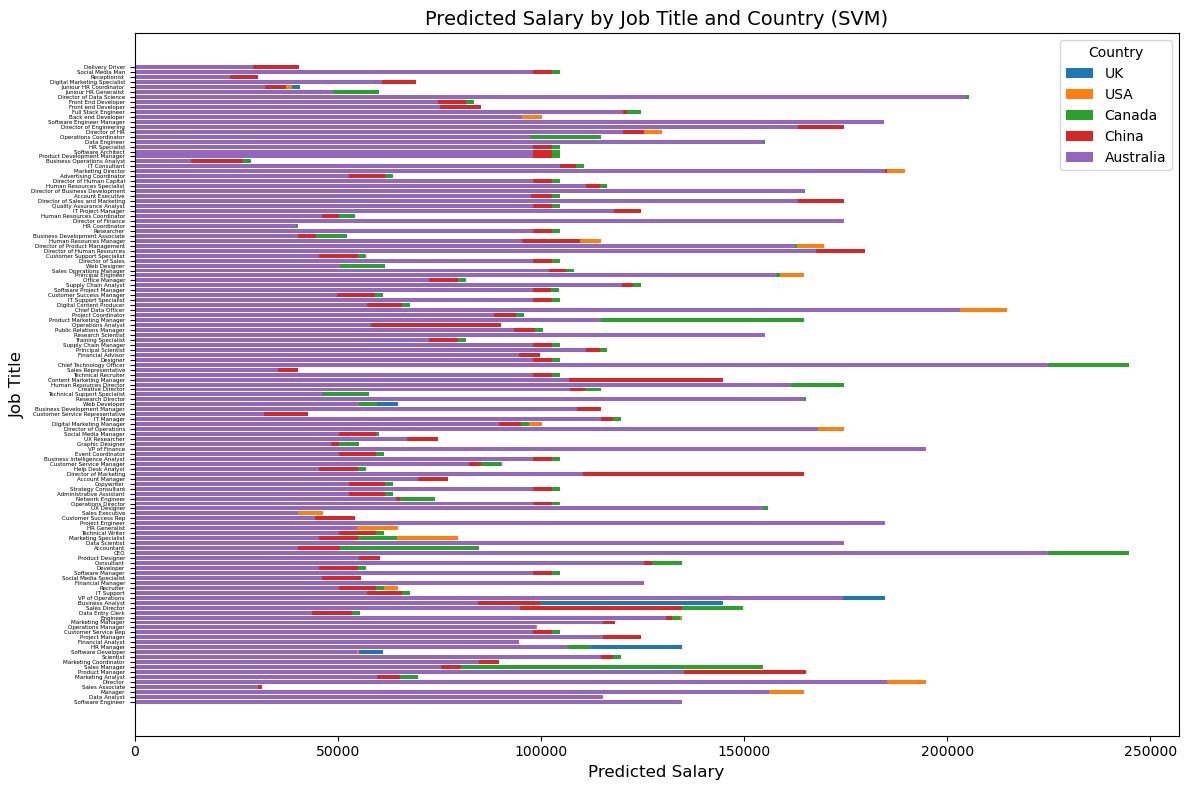

In [1]:
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_name = 'Salary.csv'
df = pd.read_csv(file_name)

# Features (Job Title and Country) and Target (Salary)
X = df[['Job Title', 'Country']]
y = df['Salary']

# Encode categorical features
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X).toarray()

# Standardize the target variable (for better SVM performance)
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_scaled, test_size=0.2, random_state=42)

# Train SVM regression model
svm_model = SVR(kernel='rbf', C=100, gamma=0.1)
svm_model.fit(X_train, y_train)

# Prepare grid for plotting
job_titles = df['Job Title'].unique()
countries = df['Country'].unique()

# Generate a grid of data points (Job Title, Country combinations)
grid_data = []
for job in job_titles:
    for country in countries:
        grid_data.append({'Job Title': job, 'Country': country})
grid_df = pd.DataFrame(grid_data)

# Encode the grid data
grid_encoded = encoder.transform(grid_df).toarray()

# Predict salaries for the grid
predicted_salaries = svm_model.predict(grid_encoded)

# Reshape and inverse transform predictions
predicted_salaries = scaler.inverse_transform(predicted_salaries.reshape(-1, 1))

# Add predictions to the grid DataFrame
grid_df['Predicted Salary'] = predicted_salaries.ravel()

# Plot predictions
plt.figure(figsize=(12, 8))
for idx, country in enumerate(countries):
    subset = grid_df[grid_df['Country'] == country]
    plt.barh(subset['Job Title'], subset['Predicted Salary'], label=country)

# Customize the axis labels and title
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Predicted Salary by Job Title and Country (SVM)', fontsize=14)

# Make job titles (y-axis labels) smaller
plt.yticks(fontsize=4)  # Adjust font size for job titles

plt.legend(title='Country')
plt.tight_layout()
plt.show()






In [4]:
# Generate a grid of data points (Job Title, Country combinations)
grid_data = []
for job in job_titles:
    for country in countries:
        grid_data.append({'Job Title': job, 'Country': country})

# Convert grid data to a DataFrame
grid_df = pd.DataFrame(grid_data)

# Encode the grid data
grid_encoded = encoder.transform(grid_df).toarray()

# Predict salaries for the grid
predicted_salaries = svm_model.predict(grid_encoded)

# Reshape and inverse transform predictions
predicted_salaries = scaler.inverse_transform(predicted_salaries.reshape(-1, 1))

# Add predictions to the grid DataFrame
grid_df['Predicted Salary'] = predicted_salaries.ravel()


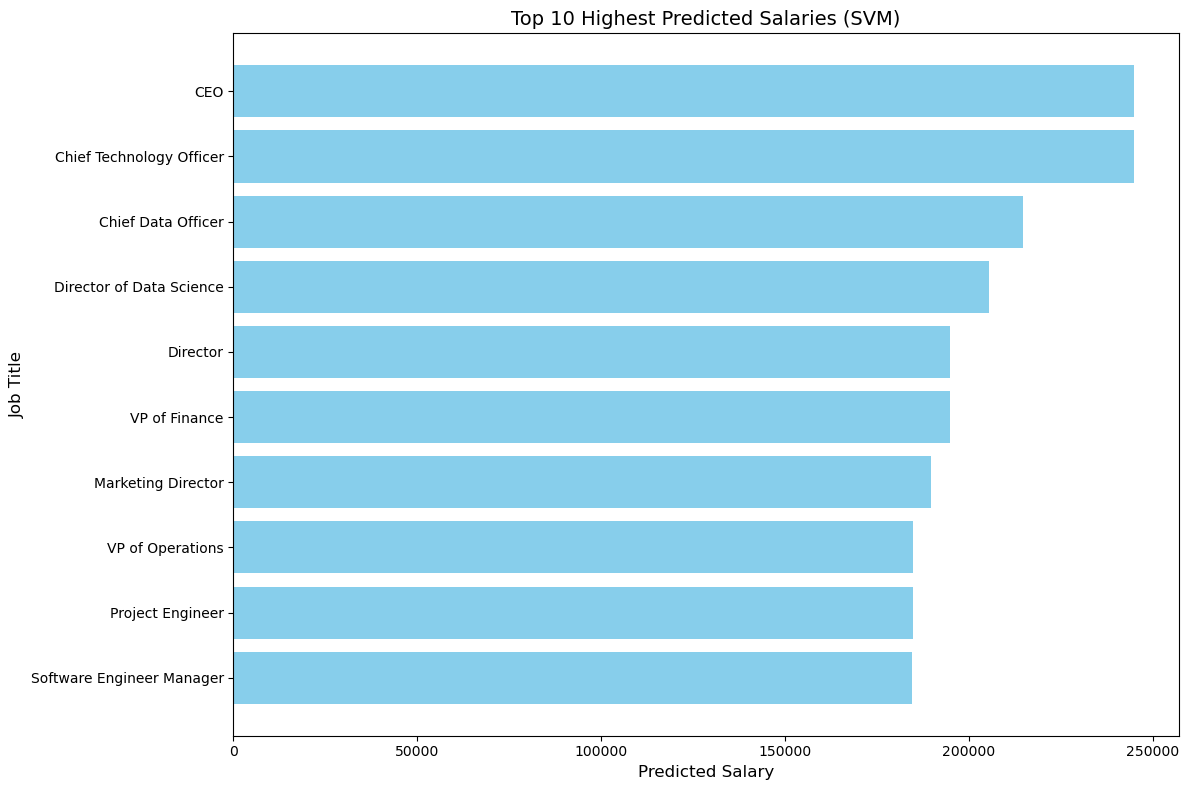

In [9]:
# Sort the predictions by predicted salary in descending order
sorted_salaries = grid_df.sort_values(by='Predicted Salary', ascending=False)

# Drop duplicates based on Job Title, keeping only the highest predicted salary for each job title
top_10_salaries = sorted_salaries.drop_duplicates(subset='Job Title').head(10)

# Plot top 10 highest predicted salaries by Job Title
plt.figure(figsize=(12, 8))

# Horizontal bar chart for only Job Title
plt.barh(top_10_salaries['Job Title'], top_10_salaries['Predicted Salary'], color='skyblue')

# Customizations for better readability
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Top 10 Highest Predicted Salaries (SVM)', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis to show the highest salary at the top
plt.tight_layout()
plt.show()


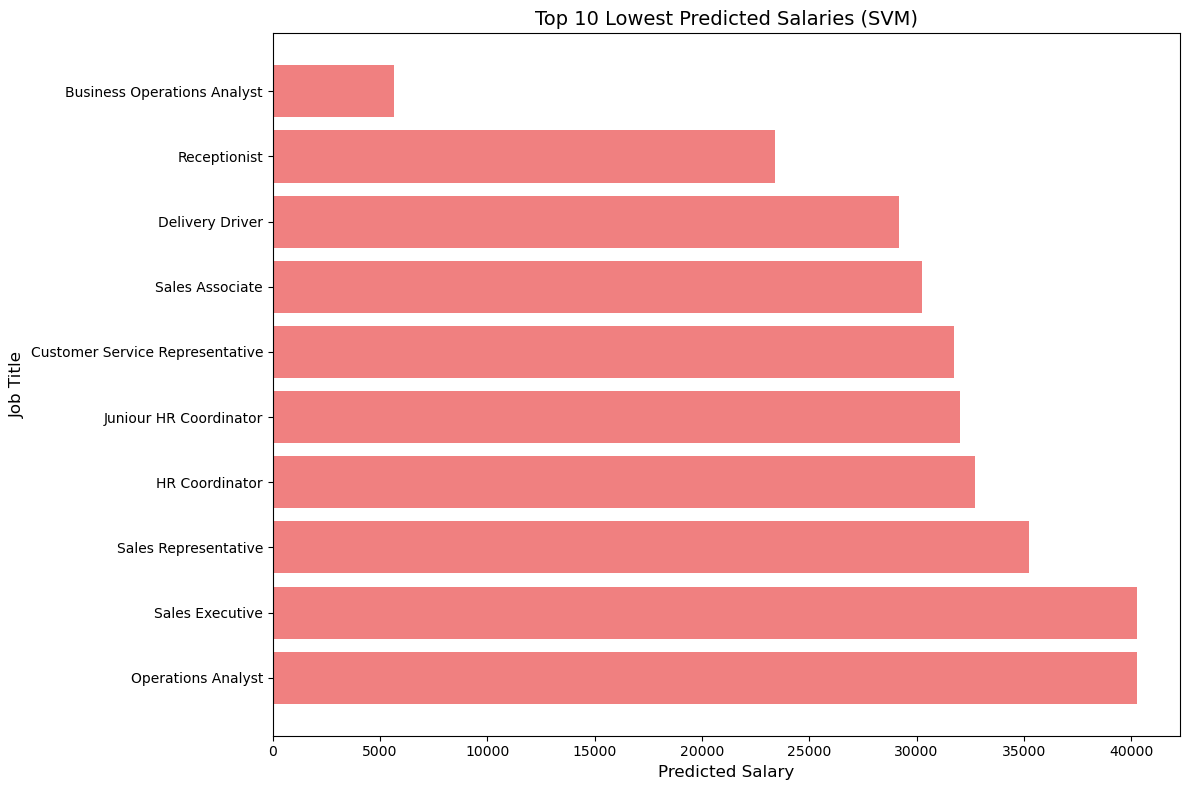

In [10]:
# Sort the predictions by predicted salary in ascending order to get the lowest salaries first
sorted_salaries = grid_df.sort_values(by='Predicted Salary', ascending=True)

# Drop duplicates based on Job Title, keeping only the lowest predicted salary for each job title
lowest_10_salaries = sorted_salaries.drop_duplicates(subset='Job Title').head(10)

# Plot top 10 lowest predicted salaries by Job Title
plt.figure(figsize=(12, 8))

# Horizontal bar chart for only Job Title (showing lowest salaries)
plt.barh(lowest_10_salaries['Job Title'], lowest_10_salaries['Predicted Salary'], color='lightcoral')

# Customizations for better readability
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Top 10 Lowest Predicted Salaries (SVM)', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis to show the lowest salary at the top
plt.tight_layout()
plt.show()


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict the salaries for the test set
y_pred = svm_model.predict(X_test)

# Inverse transform the scaled predictions and true values
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Calculate MSE
mse = mean_squared_error(y_test_original, y_pred_original)

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_pred_original)

# Calculate R-squared (R²)
r2 = r2_score(y_test_original, y_pred_original)

# Calculate Standard Error (SE)
# Standard Error = sqrt(MSE)
se = np.sqrt(mse)

# Display the metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")
print(f"Standard Error (SE): {se}")


Mean Squared Error (MSE): 1303084544.6873748
Mean Absolute Error (MAE): 26537.448217526067
R-squared (R²): 0.531080931964745
Standard Error (SE): 36098.26234997157


In [2]:
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Load dataset (make sure to adjust the file path if needed)
file_name = 'Salary.csv'
df = pd.read_csv(file_name)

# Features (Job Title and Country) and Target (Salary)
X = df[['Job Title', 'Country']]
y = df['Salary']

# Encode categorical features (Job Title, Country)
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X).toarray()

# Standardize the target variable (for better SVM performance)
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Bin the salary into categories (e.g., low, medium, high salary)
k_bins = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
y_binned = k_bins.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split (use binned salary as target for classification)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_binned, test_size=0.2, random_state=42)

# Train the SVM model for classification
svm_model_classification = SVR(kernel='rbf', C=100, gamma=0.1)  # Same as before, but for classification
svm_model_classification.fit(X_train, y_train)

# Predict the salary categories (binned values)
y_pred_binned = svm_model_classification.predict(X_test)

# Convert predictions to integers (as we binned them into categories)
y_pred_binned = y_pred_binned.round().astype(int)

# Calculate Accuracy, Precision, Recall, and F1-Score
accuracy = accuracy_score(y_test, y_pred_binned)
precision = precision_score(y_test, y_pred_binned, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_binned, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred_binned, average='weighted', zero_division=1)

# Display the metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")


c:\Users\lenov\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Accuracy: 0.6649214659685864
Precision: 0.6796201027897769
Recall: 0.6649214659685864
F1-Score: 0.663813807715558


In [3]:
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import pandas as pd

# Load dataset (make sure to adjust the file path if needed)
file_name = 'Salary.csv'
df = pd.read_csv(file_name)

# Features (Job Title and Country) and Target (Salary)
X = df[['Job Title', 'Country']]
y = df['Salary']

# Encode categorical features (Job Title, Country)
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X).toarray()

# Standardize the target variable (for better SVM performance)
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Bin the salary into categories (e.g., low, medium, high salary)
k_bins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
y_binned = k_bins.fit_transform(y.values.reshape(-1, 1)).ravel()

# Define the salary categories
categories = ['Low', 'Medium', 'High', 'Very High']

# Train-test split (use binned salary as target for classification)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_binned, test_size=0.2, random_state=42)

# Train the SVM model for classification
svm_model_classification = SVR(kernel='rbf', C=100, gamma=0.1)  # Same as before, but for classification
svm_model_classification.fit(X_train, y_train)

# Predict the salary categories (binned values)
y_pred_binned = svm_model_classification.predict(X_test)

# Convert predictions to integers (as we binned them into categories)
y_pred_binned = y_pred_binned.round().astype(int)

# Calculate Accuracy, Precision, Recall, and F1-Score
accuracy = accuracy_score(y_test, y_pred_binned)
precision = precision_score(y_test, y_pred_binned, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_binned, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred_binned, average='weighted', zero_division=1)

# Display the metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binned, target_names=categories))


c:\Users\lenov\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Accuracy: 0.5976065818997757
Precision: 0.6315145152497433
Recall: 0.5976065818997757
F1-Score: 0.5814663564623824

Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.61      0.72       285
      Medium       0.54      0.71      0.62       470
        High       0.55      0.63      0.59       437
   Very High       0.68      0.10      0.18       145

    accuracy                           0.60      1337
   macro avg       0.66      0.51      0.53      1337
weighted avg       0.63      0.60      0.58      1337

